Code to set path root

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.3
    ),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  34


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  8


### Using Model Architecture:
* 3 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

In [ ]:
model = nn.Sequential( 
    # 1st block
    nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(8),
    nn.MaxPool2d(2, 2),

    # 2nd block
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(16),
    nn.MaxPool2d(2, 2),

    # 3rd block
    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(32),
    nn.MaxPool2d(2, 2),

    # 4th block (NO POOL)
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(64),

    # 5th block (NO POOL)
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(128),

    # Flatten
    nn.Flatten(),

    # 64x64 → 32 → 16 → 8 (final map = 128 × 8 × 8)
    nn.Linear(128 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

### Use Trainer to train and check validations

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment1/",
    save_checkpoints=5,
    print_every=5
    )

In [10]:
history = trainer.fit(100)

Epoch [1/100] | Train Loss: 0.5538 | Val Loss: 1.0975 | Train Acc: 0.8573 | Val Acc: 0.3319 | Train F1: 0.8581 | Val F1: 0.1702
Epoch [2/100] | Train Loss: 0.7890 | Val Loss: 1.4651 | Train Acc: 0.7429 | Val Acc: 0.3429 | Train F1: 0.7420 | Val F1: 0.1785
Epoch [3/100] | Train Loss: 0.7722 | Val Loss: 1.4663 | Train Acc: 0.6999 | Val Acc: 0.3540 | Train F1: 0.6972 | Val F1: 0.2085
Epoch [4/100] | Train Loss: 0.7466 | Val Loss: 1.4955 | Train Acc: 0.7070 | Val Acc: 0.3650 | Train F1: 0.7051 | Val F1: 0.2261
Epoch [5/100] | Train Loss: 0.7019 | Val Loss: 1.5167 | Train Acc: 0.7264 | Val Acc: 0.3717 | Train F1: 0.7254 | Val F1: 0.2382
Epoch [6/100] | Train Loss: 0.6589 | Val Loss: 1.5449 | Train Acc: 0.7505 | Val Acc: 0.3717 | Train F1: 0.7499 | Val F1: 0.2431
Epoch [7/100] | Train Loss: 0.6211 | Val Loss: 1.7415 | Train Acc: 0.7708 | Val Acc: 0.3695 | Train F1: 0.7703 | Val F1: 0.2373
Epoch [8/100] | Train Loss: 0.5959 | Val Loss: 1.7935 | Train Acc: 0.7892 | Val Acc: 0.3894 | Train F1: 

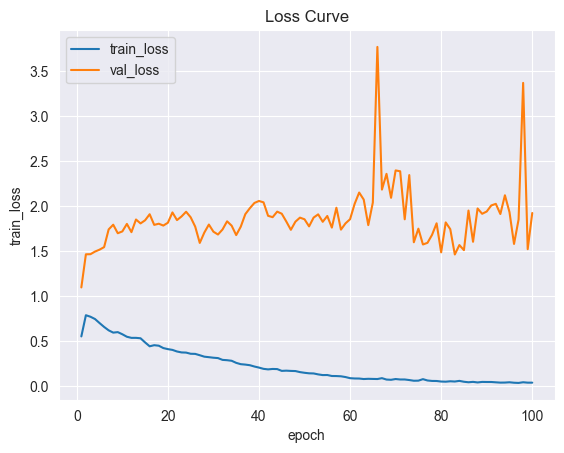

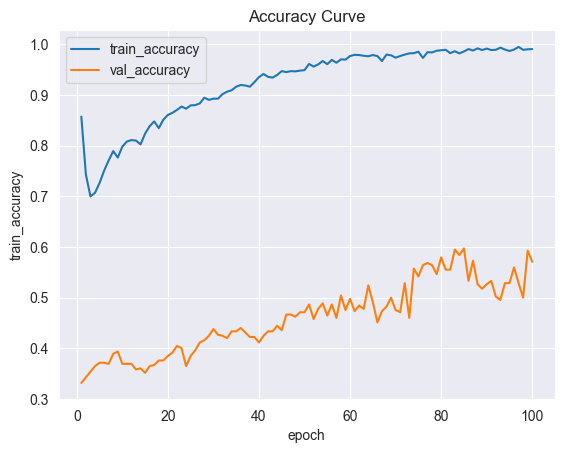

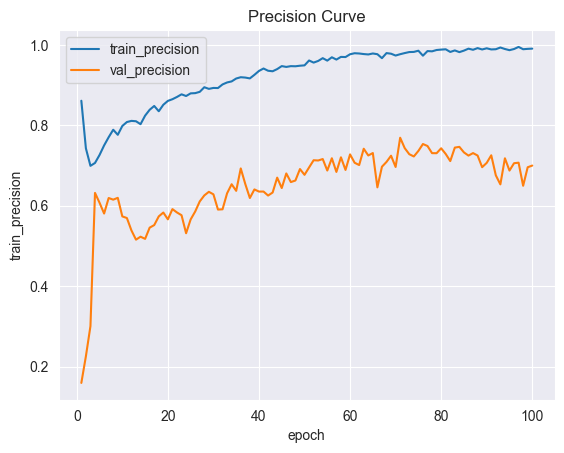

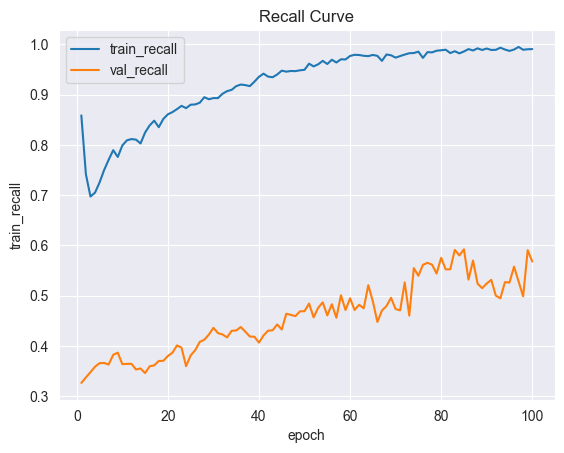

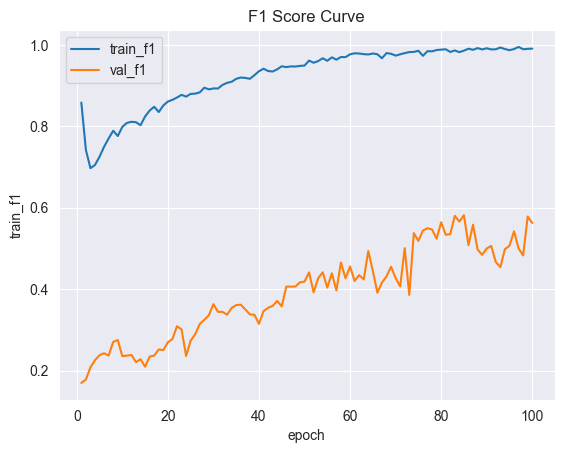

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,confusion_matrix
0,1,0.553760,1.097542,0.857278,0.860973,0.858640,0.858115,0.331858,0.159230,0.326742,0.170174,"[[tensor(0), tensor(2), tensor(140)], [tensor(..."
1,2,0.788990,1.465066,0.742911,0.742585,0.741739,0.741967,0.342920,0.225461,0.337580,0.178464,"[[tensor(0), tensor(4), tensor(138)], [tensor(..."
2,3,0.772159,1.466341,0.699905,0.699106,0.697343,0.697183,0.353982,0.300393,0.348029,0.208453,"[[tensor(0), tensor(5), tensor(137)], [tensor(..."
3,4,0.746647,1.495460,0.706994,0.706257,0.705018,0.705056,0.365044,0.631766,0.358924,0.226107,"[[tensor(1), tensor(9), tensor(132)], [tensor(..."
4,5,0.701900,1.516717,0.726371,0.726156,0.725170,0.725420,0.371681,0.607243,0.366022,0.238213,"[[tensor(4), tensor(13), tensor(125)], [tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0.039640,1.580288,0.989603,0.989621,0.989557,0.989585,0.559735,0.705607,0.557932,0.542199,"[[tensor(57), tensor(13), tensor(72)], [tensor..."
96,97,0.037509,1.850968,0.994802,0.994820,0.994751,0.994778,0.528761,0.706924,0.528543,0.500327,"[[tensor(58), tensor(8), tensor(76)], [tensor(..."
97,98,0.044942,3.367745,0.989130,0.989093,0.989103,0.989097,0.500000,0.649513,0.498819,0.482954,"[[tensor(52), tensor(13), tensor(77)], [tensor..."
98,99,0.040451,1.521986,0.990076,0.989996,0.990094,0.990041,0.592920,0.695566,0.590676,0.578499,"[[tensor(61), tensor(23), tensor(58)], [tensor..."


In [11]:
plot_training_metrics(history)